##### Instructions
- Keep the original structure, you may add additional code cells and/or mark-down cells for clarity, legibility and/or structure.
- Add the required descriptions, explanations, justifications to the mark-down cells.

# EXAM03: Data Science Group Assignment - Iteration 3

**Group name:** A

**Student names & numbers:**
* [Damian van der Sluis] - [101360]
* [Achraf El Azzouzi] - [101674]
* [Saeed Alhasan] - [102384]


---

## 0. Iteration setup

**Import libraries**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    mean_absolute_error, 
    mean_squared_error, 
    r2_score, 
    accuracy_score, 
    confusion_matrix, 
    ConfusionMatrixDisplay
)

**Load & Merge dataset(s)**

In [7]:
df_clean = pd.read_csv('iteratie2_clean.csv')
df_logs = pd.read_csv('ship_performance_logs_iter3.csv')
df = pd.merge(df_clean, df_logs, on='Ship_ID', how='left')
print(f"Aantal rijen na merge: {len(df)}")
display(df.head())

Aantal rijen na merge: 360916


,Ship_ID,Galactic_Credits,Model_Cycle,Ship_Manufacturer,Sector,Hull_Integrity,Reactor_Power,Propulsion_Type,Ship_Class,Lightyears_Traveled,Registration_Status
0,7316160254,4950,7505.0,Galactic Motors,Mon Cala Ocean Worlds,Critical,40.0,Ion Drive,Shuttle,104.554402,Smuggler Logic
1,7316115206,18999,7518.0,Galactic Motors,Thraxos Blockade,Pristine,120.0,Solar Sail,Shuttle,21.540154,Imperial Certified
2,7315865657,4000,7486.0,Republic Aerospace,Indoumodo Sector,Critical,40.0,Ion Drive,Shuttle,87.313033,Imperial Certified
3,7314772431,6495,7511.0,Nebula Industries,Pantora Moon,Pristine,40.0,Graviton Beam,Shuttle,144.885019,Imperial Certified
4,7311539325,3995,7499.0,Corellian Engineering,Malastare Narrows,Critical,40.0,Hyperdrive,Shuttle,124.394203,Smuggler Logic


---

## 1. Business Understanding

**Situation description**
Nebula Brokerage begon met het raden van prijzen via simpele wiskundige gemiddeldes (iteratie 1), wat leidde tot enorme foutmarges omdat unieke eigenschappen van de schepen werden genegeerd. In iteratie 2 is er gekeken naar specifieke eigenschappen, maar nu we de dataset verrijken met complexe performance logs (zoals gereisde lichtjaren en registratiestatus) blijken handmatige regels en simpele gemiddeldes onvoldoende om de complexiteit van de markt te bevatten. We moeten daarom overstappen op geavanceerde Machine Learning om alle variabelen feilloos samen te laten werken.

**Business objective(s)**
Het opzetten van een volledig AI-gedreven pijplijn levert directe bedrijfswaarde op. Door zowel de prijs (`Galactic_Credits`) als de conditie (`Hull_Integrity`) automatisch en accuraat te voorspellen, kan Nebula Brokerage razendsnel en objectief schepen inkopen en verkopen. Dit minimaliseert het risico op het inkopen van 'wrakken' voor de hoofdprijs, maximaliseert de winstmarge door de juiste verkoopprijs te bepalen, en bespaart ontzettend veel tijd die anders naar handmatig inspecteren en inschatten zou gaan.

**Data mining goal(s)**
In deze iteratie voeren we twee concrete Machine Learning taken uit:
1. **Regressie (Task A):** Het trainen van een Linear Regression model om een doorlopende numerieke waarde te voorspellen: de marktwaarde in `Galactic_Credits`.
2. **Classificatie (Task B):** Het trainen van een Decision Tree model om een categorie (label) te voorspellen: de structurele conditie van het schip (`Hull_Integrity`).

**Success criteria**
Deze iteratie is succesvol wanneer:
* Het regressiemodel (prijsvoorspelling) aanzienlijk beter presteert dan de baselines uit Iteratie 1 (oftewel: de MAE en RMSE scores moeten aantoonbaar lager en dus beter zijn).
* Het classificatiemodel (conditievoorspelling) een betrouwbare *Accuracy* behaalt, wat we kunnen onderbouwen door het correct inzetten en analyseren van een Confusion Matrix om inzicht te krijgen in de gemaakte voorspellingsfouten.

---

## 2. Data Understanding

**Data exploration (New Features)**
In deze derde iteratie hebben we twee nieuwe variabelen binnengekregen via de performance logs:
- Lightyears_Traveled: Een numerieke variabele die de 'kilometerstand' ('mileage') van het schip aangeeft.
- Registration_Status: Een categorische variabele die aangeeft in welke juridische staat het schip verkeert (bijv. Clean, Stolen of Salvage).

Hieronder gebruiken we de bekende Pandas functies zoals .info(), .describe() en .value_counts() om snel een eerste indruk te krijgen van de inhoud van deze nieuwe kolommen, inclusief mogelijke ontbrekende waarden.

In [ ]:
print("Algemene DataFrame Informatie")
df.info()

print("\nStatistieken van Numerieke Data")
display(df.describe())

print("\nVerdeling van Registration_Status")
if 'Registration_Status' in df.columns:
    display(df['Registration_Status'].value_counts(dropna=False))

Algemene DataFrame Informatie
<class 'pandas.DataFrame'>
RangeIndex: 360916 entries, 0 to 360915
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Ship_ID              360916 non-null  int64  
 1   Galactic_Credits     360916 non-null  int64  
 2   Model_Cycle          360916 non-null  float64
 3   Ship_Manufacturer    360916 non-null  str    
 4   Sector               360916 non-null  str    
 5   Hull_Integrity       360916 non-null  str    
 6   Reactor_Power        360916 non-null  float64
 7   Propulsion_Type      360916 non-null  str    
 8   Ship_Class           360916 non-null  str    
 9   Lightyears_Traveled  353811 non-null  float64
 10  Registration_Status  353811 non-null  str    
dtypes: float64(3), int64(2), str(6)
memory usage: 30.3 MB

Statistieken van Numerieke Data (inclusief Lightyears_Traveled)


,Ship_ID,Galactic_Credits,Model_Cycle,Reactor_Power,Lightyears_Traveled
count,3.609160e+05,360916.000000,360916.000000,360916.000000,353811.000000
mean,7.311484e+09,19450.608815,7511.263984,70.672206,104.839485
std,4.382041e+06,15541.451500,9.079721,42.943007,88.941682
min,7.301583e+09,501.000000,7400.000000,30.000000,0.000000
25%,7.308097e+09,7950.000000,7508.000000,40.000000,30.622182
50%,7.312602e+09,15990.000000,7513.000000,60.000000,85.496024
75%,7.315244e+09,27990.000000,7517.000000,80.000000,157.572045
max,7.317101e+09,777777.000000,7522.000000,360.000000,1559.606111



Verdeling van Registration_Status


Registration_Status
Imperial Certified    171756
Refurbished            74363
Smuggler Logic         43277
Stolen                 28818
Scrap                  28808
NaN                     7105
Unknown                 6789
Name: count, dtype: int64

**Visualizations and patterns**
Om beter te begrijpen hoe deze twee nieuwe kolommen mogelijk samenhangen met onze doelen (de prijs en de conditie), maken we hieronder twee grafieken:
1. Een **Scatterplot** (spreidingsdiagram) die controleert op een trend of patroon tussen het aantal gereisde lichtjaren (`Lightyears_Traveled`) en de verkoopprijs (`Galactic_Credits`).
2. Een **Bar chart** (gestapeld staafdiagram) die in kaart brengt of een gestolen of afgeschreven schip (`Registration_Status`) vaker een kritieke, beschadigde conditie (`Hull_Integrity`) heeft.

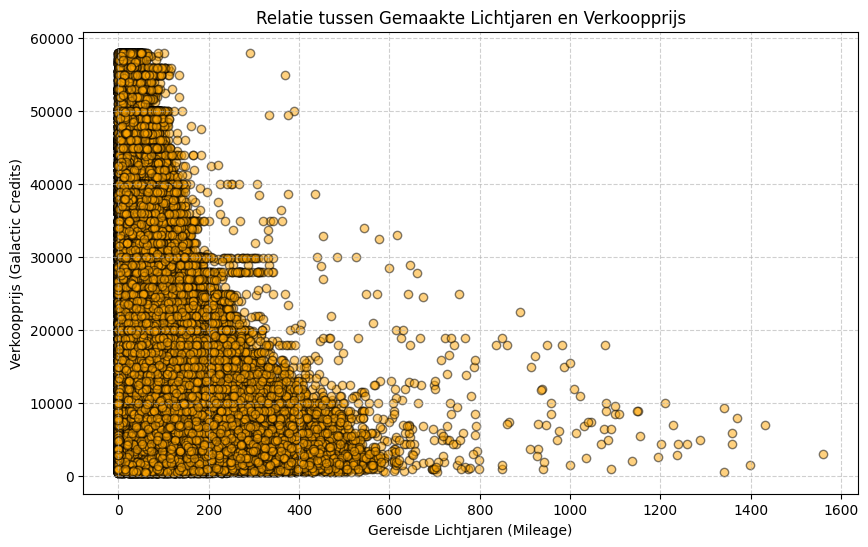

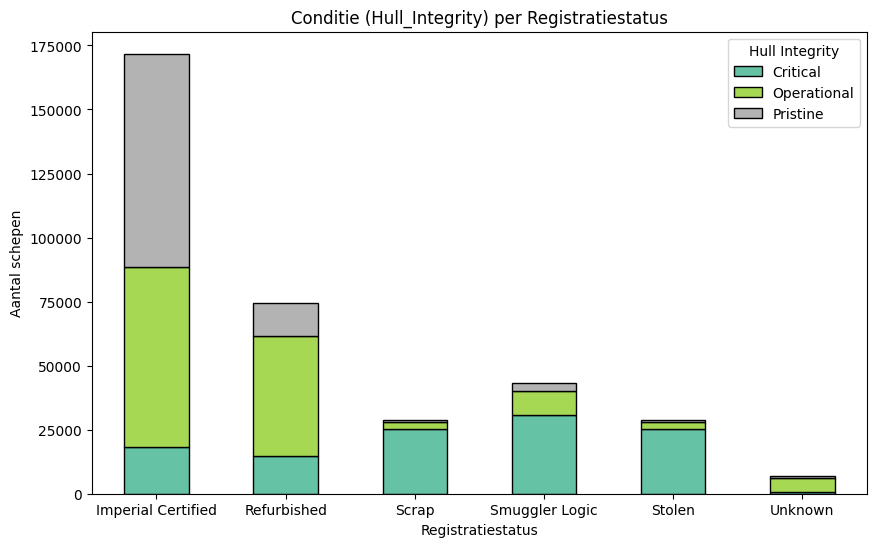

In [9]:
if 'Lightyears_Traveled' in df.columns:
    plt.figure(figsize=(10, 6))
    plt.scatter(df['Lightyears_Traveled'], df['Galactic_Credits'], alpha=0.5, color='orange', edgecolor='black')
    plt.title('Relatie tussen Gemaakte Lichtjaren en Verkoopprijs')
    plt.xlabel('Gereisde Lichtjaren (Mileage)')
    plt.ylabel('Verkoopprijs (Galactic Credits)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
    
if 'Registration_Status' in df.columns and 'Hull_Integrity' in df.columns:
    status_integrity_counts = df.groupby(['Registration_Status', 'Hull_Integrity']).size().unstack(fill_value=0)
    
    status_integrity_counts.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set2', edgecolor='black')
    plt.title('Conditie (Hull_Integrity) per Registratiestatus')
    plt.xlabel('Registratiestatus')
    plt.ylabel('Aantal schepen')
    plt.xticks(rotation=0)
    plt.legend(title='Hull Integrity')
    plt.show()

**Data insights and data quality**

* **Insights (Lightyears vs Prijs):** In de scatterplot is duidelijk te zien dat er een negatieve correlatie is tussen gereisde lichtjaren (`Lightyears_Traveled`) en de prijs (`Galactic_Credits`). Schepen een astronomische kilometerstand zijn systematisch minder waard. Deze relatie is enorm nuttig voor ons regressiemodel (Task A) om exacte afschrijvingen te berekenen in plaats van ruwe gemiddeldes te gebruiken.
* **Insights (Status vs Conditie):** Uit de verdeling  (via `.value_counts()`) zien we dat een groot deel van de schepen legale documenten heeft ('Imperial Certified': ~171.7k), maar dat er ook veel twijfelachtige schepen bij zitten (zoals 'Refurbished': ~74.3k, 'Smuggler Logic': ~43.2k, 'Stolen': ~28.8k en 'Scrap': ~28.8k). In de daaropvolgende Barchart ontdekken we bovendien dat schepen met een 'Stolen' of 'Scrap' registratie ontzettend vaak het label `Critical` (ernstige rompschade) hebben vergeleken met schone registraties. Dit is een enorm sterke *voorspeller* voor onze Decision Tree (Task B).
* **Quality issues (Lege waarden & Noise):** Via de pandas `df.info()` output - en de resultaten in de codeblokken hierboven - zien we dat beide performance logs alles behalve netjes zijn aangeleverd. Er missen zo rond de 7000 waarden (gevreesde `NaN` / null-values) over het aantal gemaakte lichtjaren, en bij `Registration_Status` missen er nog eens ~7100 waarden en staan er nog ~6789 gekenmerkt als 'Unknown'. Dit dwingt ons deze problemen aan te pakken in het volgende 'Data Preparation' hoofdstuk, omdat anders onze `scikit-learn` algoritmes geheid zullen vastlopen.

---

## 3. Data Preparation

**Cleaning and preprocessing**
Om de data voor te bereiden op de Machine Learning modellen, moeten we de fouten en lege cellen oplossen die we in Hoofdstuk 2 hebben gevonden:
1. **Lightyears_Traveled:** We zagen dat er hier waarden (NaN) ontbraken. We lossen dit op door deze lege velden op te vullen met de *mediaan* (Imputation). We kiezen bewust voor de mediaan en niet voor het gemiddelde, omdat we bij extreme uitschieters (gigantische afstanden) anders de werkelijkheid vervormen.
2. **Registration_Status:** Omdat dit categorische tekstdata betreft, kunnen we hier geen wiskundig gemiddelde over uitrekenen. Omdat "Unknown" of "NaN" geen voorspellende waarde heeft voor ons model, en onze dataset toch groot genoeg is (~360k rijen), kiezen we er simpelweg voor om de rijen met missende en onbekende statussen in zijn geheel te verwijderen (Drop).

In [ ]:
mediaan_lightyears = df['Lightyears_Traveled'].median()
df['Lightyears_Traveled'] = df['Lightyears_Traveled'].fillna(mediaan_lightyears)
df = df.dropna(subset=['Registration_Status'])
df = df[df['Registration_Status'] != 'Unknown']

print(f"Aantal rijen na de laatste schoonmaakronde: {len(df)}")
print("\nMogelijke missende waardes (NaN) die er nog zijn in de belangrijke features:\n", df[['Lightyears_Traveled', 'Registration_Status']].isnull().sum())

**Feature encoding & Splitting**
De wiskundige algoritmes van Machine Learning werken uitsluitend met getallen, niet met tekst. Als we categorische variabelen met tekst bevatten (*zoals Sector of Registration_Status*), weten de modellen in de komende hoofdstukken hier simpelweg geen raad mee en crashen ze.

Daarom leggen we in het onderstaande blok alle nuttige eigenschappen vast en zetten we onze tekst-kolommen om met behulp van **One-Hot Encoding** (`pd.get_dummies()`). Hierbij splitsen we bijvoorbeeld de `Registration_Status` kolom (met 'Stolen' en 'Refurbished' etc.) op; elke aparte mogelijkheid krijgt zijn eigen binaire "Ja/Nee" (1/0) kolommetje, waardoor het model hiermee rekenkundig overweg kan. Hiermee is onze Input Feature Matrix (`X`) afgerond.

*PS: In de hierna volgende hoofdstukken (4 en 5) zullen we deze data in tweeën moeten hakken: een Set om op te Trainen (80%) en eentje om mee te Testen (20%). We splitsen dit op, omdat net als een scholier met een antwoordenboekje een model de antwoorden niet alvast mag kennen tijdens het examen. Anders kunnen we het deeltje lerend vermogen en zijn voorspellingen ("Performance") niet eerlijk controleren en evalueren.*

In [ ]:
categorical_features = ['Ship_Manufacturer', 'Sector', 'Propulsion_Type', 'Ship_Class', 'Registration_Status']
features_to_encode = [col for col in categorical_features if col in df.columns]

df_encoded = pd.get_dummies(df, columns=features_to_encode, drop_first=True)

X = df_encoded.drop(columns=['Ship_ID', 'Galactic_Credits', 'Hull_Integrity'])

print(f"Dimensies van Model Input Matrix: {X.shape}")
display(X.head())

---

## 4. Modeling: Task A

**Regression setup**

*Set up a [Linear Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) model to predict `Galactic_Credits`. Make sure to split your data into training and testing sets.*

In [3]:
# CODE CELL: Train-Test split & train the Linear Regression model

**Testing and performance (Regression)**

*Calculate the MAE, RMSE and R2 score. Create a plot showing Actual vs. Predicted prices to visually verify model performance.*

In [4]:
# CODE CELL: Evaluate the rgression model and plot Actual vs Predicted

---

## 5. Modeling: Task B

**Classification setup**

*Set up a [Decision Tree Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) to predict `Hull_Integrity`. Split the data into training and testing sets.*

In [7]:
# CODE CELL: Train-Test split & train the Decision Tree model.

**Testing and performance (classification)**

*Calculate the Accuracy and plot a confusion matrix. Explain what the matrix tells you about the predictions.*

In [6]:
# CODE CELL: Evaluate your classification model (check ou tthe metrics, include a confusion matrix)

---

## 6. Evaluation

**Assessment against success criteria** 

*Compare your models to the baselines:*
* *Are thr scores of this regression model better than Iteration 1? Why?*
* *Are the scores of the decision tree better than your manual rules from Iteration 2? Why?*

**Key findings and limitations**

*What are the final conclusions? Should Nebula Brokerage deploy these models? What are the remaining limitations?*

Use [pandas' to_csv](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html) to export your cleaned and merged dataset.

---

## 7. Personal Contribution

| Student name | Contribution | Personal lessons learned |
| :--- | :--- | :--- |
| Student name 1 | *Contribution description* | *Personal lessons learned this iteration* |
| Student name 2 | *Contribution description* | *Personal lessons learned this iteration* |
| Student name 3 | *Contribution description* | *Personal lessons learned this iteration* |